In [2]:
import os
from pathlib import Path
import subprocess

# Get the top-level directory of the current git repo
PROJECT_ROOT = Path(
    subprocess.check_output(
        ["git", "rev-parse", "--show-toplevel"], text=True
    ).strip()
)

os.chdir(PROJECT_ROOT)

%pwd




'/Users/zanderholleran/Desktop/python_projects/mesa_lcc_model'

In [3]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator
import traffic.utils.distribution_utils as du
pd.set_option('display.max_columns', None)

# Process the real count data from Udot


## Day counts

In [5]:
count_df = pd.read_csv('data/vehicle_counts/210_real_count_data.csv')
count_df.columns = [i.lower() for i in count_df.columns]
count_df['date'] = pd.to_datetime(count_df['date'], format="%m/%d/%y")

hr_cols = list(count_df.columns[5:])
day_counts = count_df.groupby(by='date', as_index=False)[hr_cols].sum()

day_counts['month'] = day_counts['date'].dt.month
day_counts['week'] = day_counts['date'].dt.isocalendar().week
day_counts['weekday'] = day_counts['date'].dt.weekday  # 0=Monday, 6=Sunday
day_counts = day_counts[['date', 'month','week', 'weekday'] + hr_cols]
day_counts['decile'] = np.ceil(day_counts.total.rank(pct=True)*10)
day_counts['percentile'] = np.ceil(day_counts.total.rank(pct=True)*100)
day_counts['pct'] = day_counts.total.rank(pct=True)

day_counts.head(3)



,date,month,week,weekday,h0000,h0100,h0200,h0300,h0400,h0500,h0600,h0700,h0800,h0900,h1000,h1100,h1200,h1300,h1400,h1500,h1600,h1700,h1800,h1900,h2000,h2100,h2200,h2300,total,decile,percentile,pct
0,2023-01-03,1,1,1,38.0,17.0,10.0,8.0,23.0,56.0,296.0,853.0,951.0,871,543,633,674,673,890,837,907,867,219.0,140,90,70,78,69,9813,8.0,76.0,0.750903
1,2023-01-04,1,1,2,33.0,10.0,6.0,7.0,19.0,82.0,240.0,735.0,1175.0,569,816,638,733,854,871,1093,1192,686,248.0,135,104,93,117,72,10528,8.0,78.0,0.779783
2,2023-01-05,1,1,3,35.0,18.0,6.0,5.0,8.0,67.0,204.0,601.0,979.0,767,619,634,703,652,831,944,776,472,225.0,155,126,131,126,76,9160,8.0,72.0,0.711191


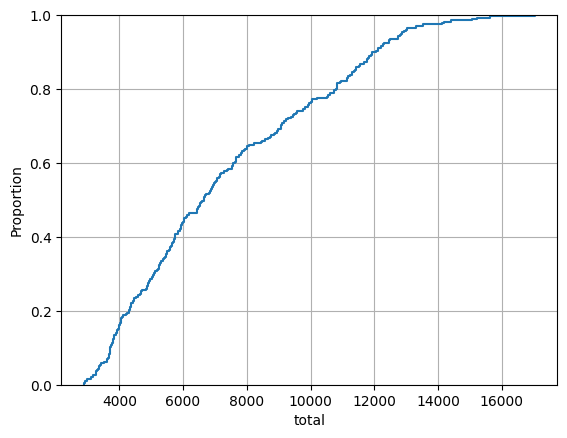

In [6]:
sns.ecdfplot(day_counts.total)
plt.grid()

<Axes: xlabel='weekday', ylabel='total'>

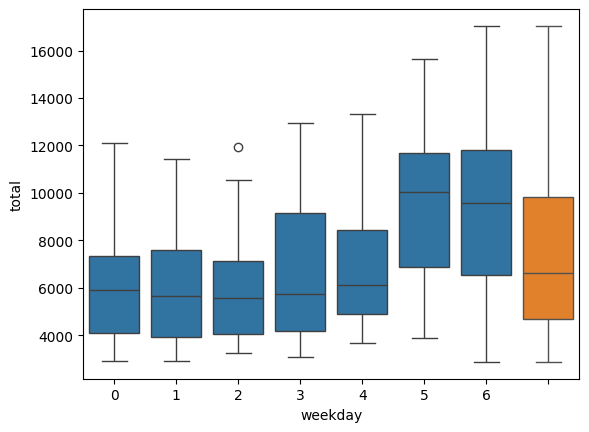

In [7]:
# box plots by day of week
sns.boxplot(data=day_counts, x='weekday', y='total')

# box plot total
sns.boxplot(day_counts.total)

# Weekly average

In [8]:
agg_dict = {col: 'mean' for col in hr_cols}
agg_dict['weekday'] = 'count'
week_avgs = day_counts.groupby(by='week', as_index=False).agg(agg_dict)

week_avgs['month'] = (week_avgs['week']+3)/4
week_avgs['days_recorded'] = week_avgs.weekday.rename('days_recorded')
week_avgs.drop(columns = 'weekday', inplace=True)
week_avgs = week_avgs[['week', 'month','days_recorded']+hr_cols]

week_avgs['adj_total'] = 7*(week_avgs['total']/week_avgs['days_recorded']) # we got some wack shit going on here
week_avgs.head(3)




,week,month,days_recorded,h0000,h0100,h0200,h0300,h0400,h0500,h0600,h0700,h0800,h0900,h1000,h1100,h1200,h1300,h1400,h1500,h1600,h1700,h1800,h1900,h2000,h2100,h2200,h2300,total,adj_total
0,1,1.0,5,39.0,13.2,5.8,4.6,14.8,68.4,241.2,680.4,950.2,856.8,761.0,714.0,790.2,823.2,942.2,1092.0,1047.6,781.2,358.8,154.0,109.8,103.6,103.6,68.8,10724.4,15014.16
1,2,1.25,5,42.8,21.4,7.0,5.8,20.8,76.0,281.8,787.4,904.2,868.6,585.2,612.0,740.2,849.0,875.6,991.6,907.4,687.6,293.2,177.6,126.4,106.0,92.2,57.8,10117.6,14164.64
2,3,1.5,5,38.0,11.6,6.2,5.8,19.2,90.2,307.2,748.8,1032.0,937.0,623.2,644.4,794.4,884.2,974.2,1037.4,1047.8,849.8,345.8,145.6,109.8,114.0,102.4,70.0,10939.0,15314.60


In [9]:
# week_avgs.days_recorded.value_counts()

# week_avgs.sort_values(by='adj_total', ascending =False)

# week_avgs.sort_values(by='days_recorded')

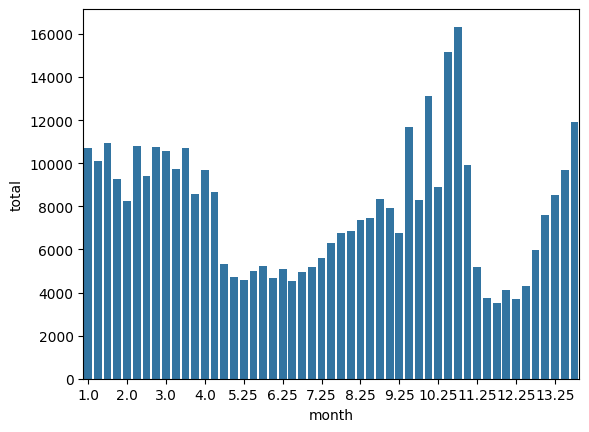

In [10]:
sns.barplot(data=week_avgs, x='month', y='total')
# Set tick every 4 weeks
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(4))

# hourly long - The buisness! 

## Takes the day counts and makes it long

In [11]:
# Select all columns that start with "h"
hour_cols = [col for col in day_counts.columns if col.startswith('h')]

# Melt into long format
df_long = day_counts.melt(
    id_vars=[col for col in day_counts.columns if col not in hour_cols],
    value_vars=hour_cols,
    var_name='hour_str',
    value_name='counts'
)

# Convert 'h0000' → 0, 'h2100' → 21, etc.
df_long['hour'] = df_long['hour_str'].str[1:3].astype(int)
slim_hours = df_long[['hour','counts']]
slim_hours = slim_hours.loc[slim_hours.hour.between(5,21)] # <-- filter out hours before 5 and after 9(21)

slim_hours['hourly_percentile'] = (
    slim_hours.groupby('hour')['counts']
    .transform(lambda x: np.ceil(x.rank(pct=True)*100))
)
print('slim_hours is fully udot data ')
display(slim_hours.head())

# expected_counts is the pivoted version of slim hours
expected_counts = slim_hours.pivot_table(index='hour', columns='hourly_percentile', values='counts')
# expected_counts results in some nuls, i used a rolling average fill
expected_counts_filled = expected_counts.apply(
    lambda row: row.fillna(row.rolling(window=3, center=True, min_periods=1).mean()),
    axis=1
)



slim_hours is fully udot data 


,hour,counts,hourly_percentile
1385,5,56.0,72.0
1386,5,82.0,96.0
1387,5,67.0,84.0
1388,5,75.0,90.0
1389,5,62.0,80.0


## Expected hourly counts --> expected secound counts, using linear interpolation 

In [12]:
hourly_df = expected_counts_filled.copy()
og_len = len(hourly_df)

# still low low count but the index is spaced out more
hourly_df.index = np.arange(0, og_len*3600, 3600)  # Index in seconds from 0 to 61200

# this produces all the rows 
second_index = np.arange(0, og_len * 3600)
df_interp = hourly_df.reindex(second_index)

# fills in all the nulls
df_interp = df_interp.interpolate(method='linear', axis=0)

# Normalize to per-second generation rate
expected_counts_seconds = df_interp / 3600

expected_counts_seconds.columns = list(range(1,101))

print(expected_counts_seconds.shape)
expected_counts_seconds

(61200, 100)


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100
0,0.000000e+00,0.003241,0.004722,0.005000,0.005278,0.005833,0.006111,0.006389,0.006667,0.006944,0.006944,0.007222,0.007222,0.007361,0.007500,0.007639,0.007778,0.007778,0.008056,0.008056,0.008056,0.008333,0.008333,0.008472,0.008611,0.008750,0.008889,0.009062,0.009236,0.009479,0.009722,0.009861,0.010000,0.010278,0.010417,0.010556,0.010694,0.010833,0.010833,0.011111,0.011111,0.011250,0.011389,0.011528,0.011667,0.011667,0.011944,0.011944,0.011944,0.012222,0.012222,0.012361,0.012500,0.012778,0.012778,0.013056,0.013056,0.013056,0.013333,0.013333,0.013611,0.013889,0.013889,0.014167,0.014167,0.014306,0.014444,0.014583,0.014722,0.015000,0.015278,0.015556,0.015694,0.015833,0.016111,0.016389,0.016667,0.016944,0.017083,0.017222,0.017708,0.018021,0.018333,0.018611,0.018889,0.019306,0.019722,0.020139,0.020556,0.020833,0.021111,0.021389,0.021528,0.021667,0.022361,0.022870,0.024074,0.025463,0.027222,0.056574
1,1.929012e-07,0.003240,0.004722,0.004999,0.005279,0.005835,0.006114,0.006392,0.006670,0.006948,0.006949,0.007227,0.007227,0.007366,0.007505,0.007644,0.007783,0.007784,0.008061,0.008062,0.008062,0.008340,0.008340,0.008479,0.008618,0.008757,0.008896,0.009070,0.009243,0.009486,0.009730,0.009868,0.010007,0.010285,0.010424,0.010563,0.010702,0.010841,0.010841,0.011119,0.011119,0.011258,0.011397,0.011536,0.011675,0.011675,0.011953,0.011953,0.011953,0.012231,0.012231,0.012370,0.012509,0.012787,0.012787,0.013065,0.013066,0.013066,0.013343,0.013344,0.013621,0.013899,0.013899,0.014177,0.014178,0.014317,0.014456,0.014595,0.014734,0.015012,0.015289,0.015567,0.015706,0.015845,0.016123,0.016401,0.016679,0.016957,0.017096,0.017235,0.017721,0.018034,0.018346,0.018624,0.018902,0.019319,0.019736,0.020153,0.020570,0.020848,0.021126,0.021405,0.021545,0.021684,0.022381,0.022892,0.024098,0.025488,0.027250,0.056600
2,3.858025e-07,0.003240,0.004721,0.004999,0.005280,0.005838,0.006116,0.006395,0.006674,0.006952,0.006953,0.007231,0.007232,0.007371,0.007510,0.007650,0.007789,0.007789,0.008067,0.008068,0.008068,0.008346,0.008346,0.008485,0.008624,0.008763,0.008902,0.009077,0.009251,0.009494,0.009737,0.009876,0.010015,0.010293,0.010432,0.010571,0.010710,0.010849,0.010850,0.011127,0.011128,0.011267,0.011406,0.011545,0.011684,0.011684,0.011961,0.011962,0.011962,0.012240,0.012240,0.012379,0.012518,0.012797,0.012797,0.013075,0.013075,0.013076,0.013354,0.013354,0.013632,0.013909,0.013910,0.014188,0.014188,0.014328,0.014467,0.014606,0.014745,0.015023,0.015301,0.015579,0.015718,0.015857,0.016135,0.016413,0.016691,0.016969,0.017108,0.017247,0.017734,0.018046,0.018359,0.018637,0.018916,0.019333,0.019750,0.020167,0.020584,0.020863,0.021142,0.021422,0.021561,0.021702,0.022400,0.022913,0.024123,0.025513,0.027278,0.056626
3,5.787037e-07,0.003240,0.004721,0.004998,0.005281,0.005840,0.006119,0.006398,0.006678,0.006956,0.006957,0.007235,0.007237,0.007376,0.007516,0.007655,0.007795,0.007795,0.008073,0.008074,0.008074,0.008352,0.008353,0.008492,0.008631,0.008770,0.008909,0.009084,0.009258,0.009501,0.009744,0.009883,0.010022,0.010300,0.010439,0.010578,0.010717,0.010857,0.010858,0.011135,0.011136,0.011275,0.011414,0.011553,0.011692,0.011692,0.011970,0.011970,0.011970,0.012248,0.012249,0.012388,0.012527,0.012806,0.012806,0.013085,0.013085,0.013086,0.013364,0.013364,0.013642,0.013920,0.013920,0.014199,0.014199,0.014339,0.014478,0.014617,0.014757,0.015035,0.015313,0.015591,0.015730,0.015869,0.016147,0.016425,0.016703,0.016981,0.017121,0.017260,0.017746,0.018059,0.018372,0.018651,0.018929,0.019346,0.019765,0.020182,0.020599,0.020878,0.021157,0.021438,0.021578,0.021719,0.022420,0.022935,0.024147,0.025538,0.027305,0.056652
4,7.716049e-07,0.003239,0.004720,0.004998,0.005282,0.005842,0.006122,0.006402,0.006

# Export

In [13]:
expected_secound_counts.to_csv('data/vehicle_counts/expected_counts_seconds.csv', index=False)

NameError: name 'expected_secound_counts' is not defined

<Axes: ylabel='95'>

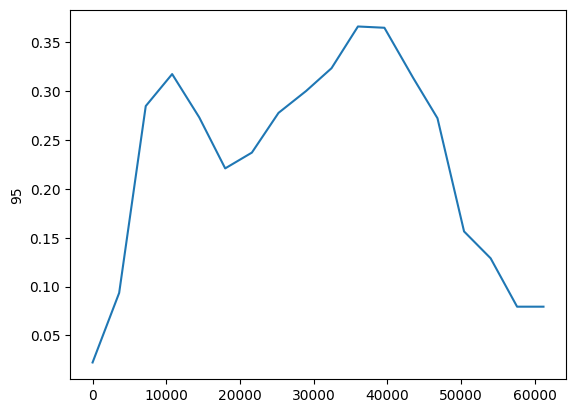

In [21]:


sns.lineplot(expected_counts_seconds[95])

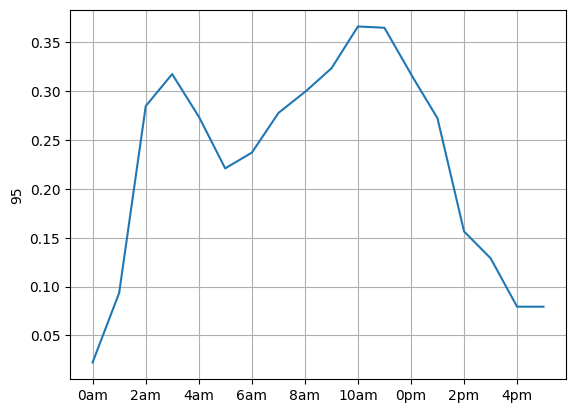

In [22]:
from matplotlib.ticker import FuncFormatter

# Plot the lineplot
sns.lineplot(expected_counts_seconds[95])

# Format the x-axis to display hours
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x // 3600)}am" if x // 3600 < 12 else f"{int(x // 3600 - 12)}pm"))
ax.xaxis.set_major_locator(MultipleLocator(7200))  # Show every other hour (2-hour intervals)

plt.grid()
plt.show()